introduction

In [2]:
from sklearn.datasets import load_diabetes
import pandas as pd

In [3]:
X, y = load_diabetes(return_X_y= True)

In [4]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [5]:
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=1))
])
pipe.get_params()

{'memory': None,
 'steps': [('scale', StandardScaler()),
  ('model', KNeighborsRegressor(n_neighbors=1))],
 'verbose': False,
 'scale': StandardScaler(),
 'model': KNeighborsRegressor(n_neighbors=1),
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'model__algorithm': 'auto',
 'model__leaf_size': 30,
 'model__metric': 'minkowski',
 'model__metric_params': None,
 'model__n_jobs': None,
 'model__n_neighbors': 1,
 'model__p': 2,
 'model__weights': 'uniform'}

In [6]:
mod = GridSearchCV(estimator=pipe,
                   param_grid={'model__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]},
                   cv= 3)

In [7]:
mod.fit(X, y);
alias = pd.DataFrame(mod.cv_results_)
alias.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.012332,0.005314,0.010335,0.003301,1,{'model__n_neighbors': 1},0.105976,0.124092,-0.158523,0.023849,0.129168,11
1,0.006335,0.002493,0.010337,0.002872,2,{'model__n_neighbors': 2},0.268889,0.339379,0.264563,0.290944,0.034295,10
2,0.013000,0.009275,0.011002,0.002942,3,{'model__n_neighbors': 3},0.333057,0.382744,0.356899,0.357567,0.020290,9
3,0.007667,0.000470,0.014002,0.000005,4,{'model__n_neighbors': 4},0.342407,0.404701,0.409910,0.385673,0.030668,7
4,0.008665,0.002360,0.013667,0.005906,5,{'model__n_neighbors': 5},0.358865,0.377198,0.412549,0.382871,0.022280,8


In [8]:
print(load_diabetes()['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt        

In [63]:
df = pd.read_csv("C:\\Users\\hp\\Desktop\\Ser\\csv\\irs.csv")

In [65]:
df.head(5)

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [67]:
X = df[['sepal.length', 'sepal.width']].values

y = df[['variety']]== "Setosa"

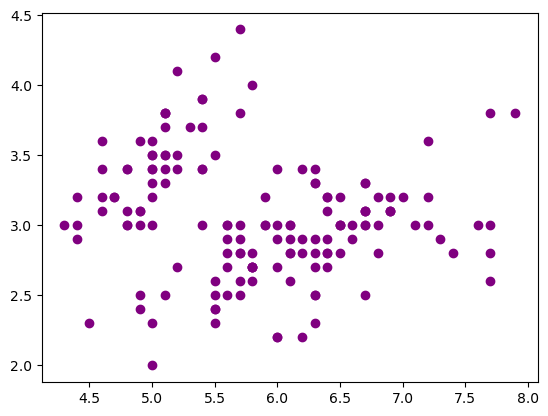

In [69]:
plt.scatter(X[:, 0], X[:, 1], c='purple');

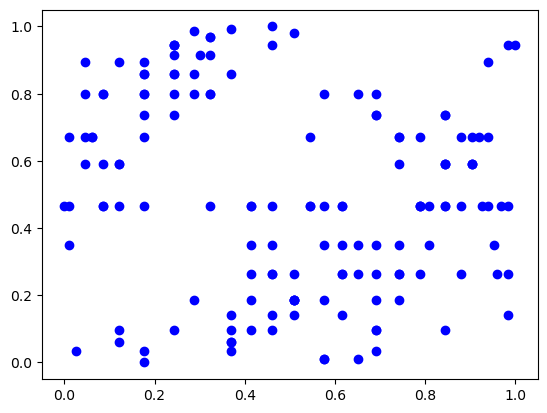

In [73]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer
X_new = QuantileTransformer(n_quantiles = 100).fit_transform(X)
plt.scatter(X_new[:, 0], X_new[:, 1], c='b');